# ICE Detention Outcomes: Predictive Modeling and Fairness Evaluation

## Research Question
**To what extent can deportation outcomes be predicted using political, demographic, and situational variables, and if so, how do these predictors differ between the Obama and Trump administrations?**

### Sub-questions:
1. Which features (criminal history, arrest method, demographics, detention duration) are the strongest predictors of a Final Order?
2. Do predictive models perform equally well across Hispanic vs. non-Hispanic and male vs. female subgroups?
3. Can fairness-aware techniques reduce demographic disparities without sacrificing overall accuracy?

### Target Variable
`final_order_numeric` — Binary: 1 = Final Order of Removal issued, 0 = Not issued

### Setup & Imports
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# Fairness
from sklearn.utils.class_weight import compute_sample_weight

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

BLUE   = "#1A237E"
PINK   = "#C2185B"
LIGHT  = "#F06292"
PALETTE = [BLUE, PINK, LIGHT, "#880E4F"]

#### Loading Data
We load the dataset that was produced in the Cleaning-EDA notebook. It already has:
- FOIA redactions replaced with NaN
- Feature-engineered binary flags
- Administration period labeled
- Redundant/leaky columns dropped

In [4]:
df = pd.read_csv("../data/ICE_Master_Cleaned.csv", low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['final_order_numeric'].value_counts())
print(f"\nAdministration breakdown:")
print(df['administration'].value_counts())
df.head()

Shape: (749491, 47)

Target distribution:
final_order_numeric
1    458765
0    290726
Name: count, dtype: int64

Administration breakdown:
administration
Trump    302241
Obama    247555
Biden    199695
Name: count, dtype: int64


,Stay Book In Date,Detention Book In Date,Detention Facility,Detention Book Out Date,Detention Release Reason,Stay Book Out Date,Stay Release Reason,Marital,Gender,Ethnicity,...,is_custodial_arrest,is_border_arrest,is_hispanic,is_male,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,State
0,2014-01-21,2014-01-21,Abilene Hold Room,2014-01-21,Voluntary Return,2014-01-21,Voluntary Return,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
1,2014-01-22,2014-01-22,Abilene Hold Room,2014-01-22,Order Of Recognizance,2014-01-22,Order Of Recognizance,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
2,2014-10-06,2014-10-06,Abilene Hold Room,2014-10-06,Order Of Recognizance,2014-10-06,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
3,2014-09-15,2014-09-15,Abilene Hold Room,2014-09-15,Order Of Recognizance,2014-09-15,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
4,2014-10-31,2014-10-31,Abilene Hold Room,2014-10-31,Transferred,2014-11-06,Bonded Out,Married,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN


### Additional Feature Engineering for Modeling
---
#### Design Principles
- **No leakage**: We exclude columns that are only known *after* a Final Order is issued 
  (e.g., `Final Order Date`, `Departed Date`, `days_to_removal`).
- **Interpretability**: We keep features that map to real-world policy levers or demographic 
  characteristics so results are actionable.
- **Parsimony**: We prefer a focused feature set over noise.

####  Leaky features excluded
| Column | Why excluded |
|--------|-------------|
| `Final Order Date` | Only exists if outcome = 1 |
| `Departed Date` | Post-outcome event |
| `days_to_removal` | Calculated from departure, leaks outcome |
| `Departed Country` | Post-outcome |
| `Stay Book Out Date` | Post-outcome |

#### Features retained
We retain pre-detention and at-detention information that would plausibly be known 
*before* a final order is issued.


In [5]:
# Leaky / post-outcome columns to drop
LEAKY_COLS = [
    'Final Order Date',
    'Departed Date',
    'days_to_removal',
    'Departure Country',
    'Stay Book Out Date',
    'Stay Book In Date',       # redundant with year
    'Detention Book In Date',  # redundant with year
    'Detention Book Out Date', # use duration instead
    'Stay Release Reason',     # post-outcome
    'Detention Release Reason',# post-outcome
    'removals_Processing Disposition',  # post-outcome
    'State',                   # sparse / already captured by facility
    'Detention Facility',      # high cardinality — keep facility type instead
]

# Drop only if present
leaky_present = [c for c in LEAKY_COLS if c in df.columns]
model_df = df.drop(columns=leaky_present).copy()

# Additional engineered features
# Repeat detention: flag if this is not their first detention
model_df['is_repeat_detention'] = (model_df['running_detention_count'] > 1).astype(int)

# Prior removal: flag if they have been removed before
model_df['has_prior_removal'] = (model_df['running_removal_count'] > 0).astype(int)

# Prior arrest: flag if they have prior arrests
model_df['has_prior_arrest'] = (model_df['running_arrest_count'] > 1).astype(int)

# Age group buckets (more stable than raw age)
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Juvenile'
    elif age < 26:
        return 'Young Adult'
    elif age < 40:
        return 'Adult'
    elif age < 56:
        return 'Middle Aged'
    else:
        return 'Senior'

model_df['age_group'] = model_df['age_at_detention'].apply(age_group)

# Detention duration bucket
def detention_bucket(days):
    if pd.isna(days):
        return 'Unknown'
    elif days == 0:
        return 'Same Day'
    elif days <= 7:
        return '1 Week'
    elif days <= 30:
        return '1 Month'
    elif days <= 90:
        return '3 Months'
    else:
        return 'Long Term'

model_df['detention_bucket'] = model_df['detention_duration_days'].apply(detention_bucket)

print(f"Model dataframe shape: {model_df.shape}")
print(f"\nNew features added: is_repeat_detention, has_prior_removal, has_prior_arrest, age_group, detention_bucket")
print(f"\nMissing values summary:")
missing = model_df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Model dataframe shape: (749491, 39)

New features added: is_repeat_detention, has_prior_removal, has_prior_arrest, age_group, detention_bucket

Missing values summary:
detention_duration_days    14976
age_at_detention             498
dtype: int64


### Feature Sets
---
We split features into:
- **Binary flags** (already 0/1) — used as-is
- **Categorical** — one-hot encoded
- **Numeric** — scaled (for logistic regression)

In [6]:
TARGET = 'final_order_numeric'

# Binary features (no encoding needed)
BINARY_FEATURES = [
    'is_CAP_arrest', 'is_287g_arrest', 'is_custodial_arrest', 'is_border_arrest',
    'is_hispanic', 'is_male', 'is_PWA', 'is_asylum_seeker',
    'has_criminal_charge', 'is_convicted', 'is_juvenile',
    'is_repeat_detention', 'has_prior_removal', 'has_prior_arrest',
]
# Only keep binary features that exist
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in model_df.columns]

# Numeric features
NUMERIC_FEATURES = [
    'age_at_detention',
    'detention_duration_days',
    'running_arrest_count',
    'running_detention_count',
    'running_removal_count',
    'year',
]
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in model_df.columns]

# Categorical features
CATEGORICAL_FEATURES = [
    'administration',
    'Case Category',
    'Case Status',
    'Case Threat Level',
    'Entry Status',
    'Gender',
    'Ethnicity',
    'Marital',
    'arrests_Apprehension Method',
    'removals_MSC Charge',
    'removals_MSC Criminal Charge Status',
    'removals_Current Program',
    'removals_Birth Country',
    'removals_Citizenship Country',
    'age_group',
    'detention_bucket',
]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in model_df.columns]

ALL_FEATURES = BINARY_FEATURES + NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Binary features  : {len(BINARY_FEATURES)}")
print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Categorical feats: {len(CATEGORICAL_FEATURES)}")
print(f"Total features   : {len(ALL_FEATURES)}")

Binary features  : 14
Numeric features : 6
Categorical feats: 16
Total features   : 36


### Preprocessing
---
We use `sklearn` pipelines to:
1. **Impute** missing values (median for numeric, 'Unknown' for categorical)
2. **Scale** numeric features (required for logistic regression)
3. **One-hot encode** categorical features (drop first to avoid multicollinearity)

Binary features are passed through unchanged.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop rows where target is missing
model_df = model_df.dropna(subset=[TARGET]).copy()

X = model_df[ALL_FEATURES].copy()
y = model_df[TARGET].astype(int)

# For fairness analysis — keep group labels aligned with X
groups = model_df[['is_hispanic', 'is_male']].copy()

print(f"X shape: {X.shape}")
print(f"Class balance:\n{y.value_counts(normalize=True).round(3)}")

# Stratified train/test split
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_pipeline,     NUMERIC_FEATURES),
    ('cat',  categorical_pipeline, CATEGORICAL_FEATURES),
    ('bin',  binary_pipeline,      BINARY_FEATURES),
])

print("\nPreprocessor defined.")

X shape: (749491, 36)
Class balance:
final_order_numeric
1    0.612
0    0.388
Name: proportion, dtype: float64

Train size: 599,592  |  Test size: 149,899

Preprocessor defined.


### Model Training
---
We train three models to compare:

| Model | Strengths | Notes |
|-------|-----------|-------|
| **Logistic Regression** | Interpretable coefficients, fast | Requires scaling, linear decision boundary |
| **Decision Tree** | Explainable rules, handles non-linearity | Prone to overfitting if deep |
| **Random Forest** | High accuracy, robust | Less interpretable, slower |

All models use class weighting (`class_weight='balanced'`) to handle the 61/39 class imbalance.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model definitions
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, min_samples_leaf=100, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, max_depth=12,
        min_samples_leaf=50, random_state=42, n_jobs=-1
    ),
}

# Fit each model in a pipeline
fitted_models = {}
train_scores  = {}

for name, clf in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   clf),
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    train_scores[name]  = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    print(f"  Train AUC: {train_scores[name]:.4f}")

print("\nAll models trained.")

Training Logistic Regression...
  Train AUC: 0.9956
Training Decision Tree...
  Train AUC: 0.9858
Training Random Forest...
  Train AUC: 0.9807

All models trained.


### Model Evaluation
---
We evaluate using:
- **AUC-ROC**: Overall discriminative ability (robust to class imbalance)
- **Average Precision (AP)**: Area under Precision-Recall curve
- **F1 Score**: Balance between precision and recall
- **Confusion Matrix**: Visualize prediction errors

**Interpretation guide**
- High AUC (>0.75) means the model can separate outcomes well
- High recall on class 1 = model correctly identifies most detainees who *will* get a Final Order
- High recall on class 0 = model correctly identifies those who will *not*

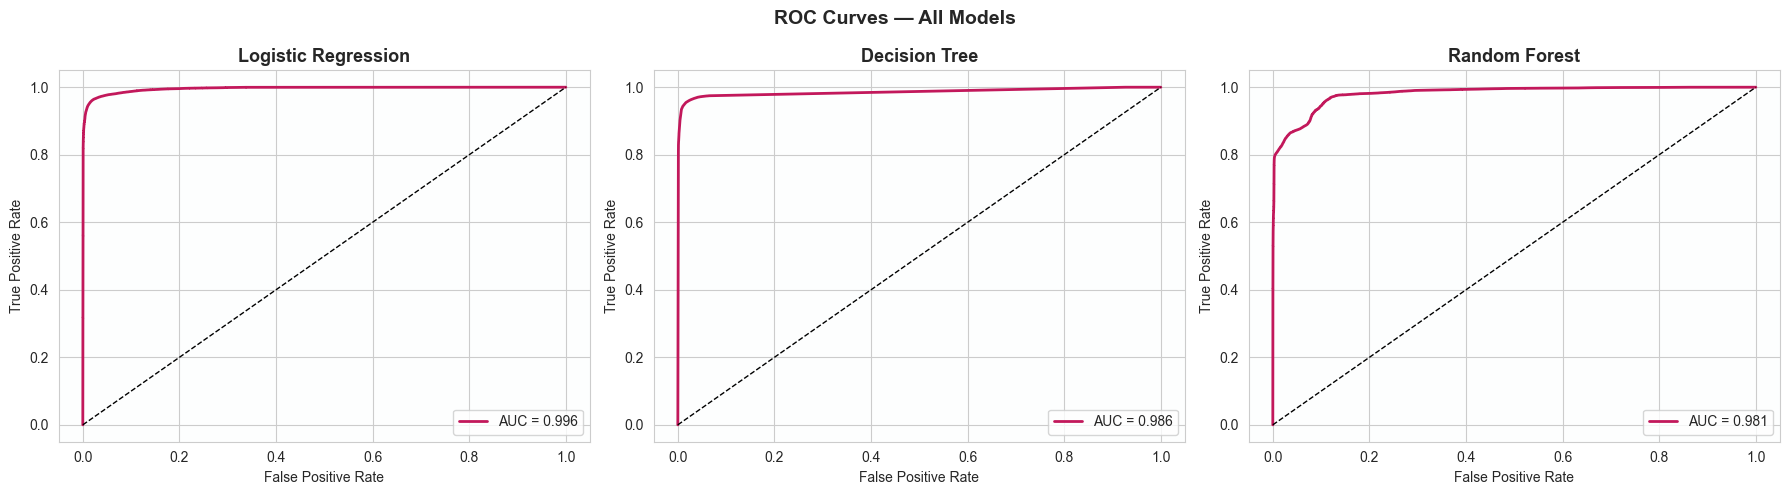


=== Model Performance Summary ===
                        AUC  Avg Precision      F1  Accuracy
Logistic Regression  0.9956         0.9971  0.9742    0.9688
Decision Tree        0.9857         0.9890  0.9718    0.9660
Random Forest        0.9808         0.9884  0.9170    0.9034


In [9]:
results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, pipe) in enumerate(fitted_models.items()):
    y_pred  = pipe.predict(X_test)
    y_prob  = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    results[name] = {'AUC': auc, 'Avg Precision': ap, 'F1': f1, 'Accuracy': acc}

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[idx].plot(fpr, tpr, color=PINK, lw=2, label=f'AUC = {auc:.3f}')
    axes[idx].plot([0,1],[0,1], 'k--', lw=1)
    axes[idx].set_title(name)
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].legend(loc='lower right')
    axes[idx].set_facecolor('#FDFEFE')

plt.suptitle('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
results_df = pd.DataFrame(results).T
print("\n=== Model Performance Summary ===")
print(results_df.round(4).to_string())

Logistic Regression performed the best across all evaluation metrics, including AUC, F1-score, and accuracy, indicating it provides the most reliable predictions. While Decision Tree showed comparable performance, Logistic Regression was selected as the final model due to its superior overall performance. However, Decision Trees may still be useful for interpretability in fairness analysis.

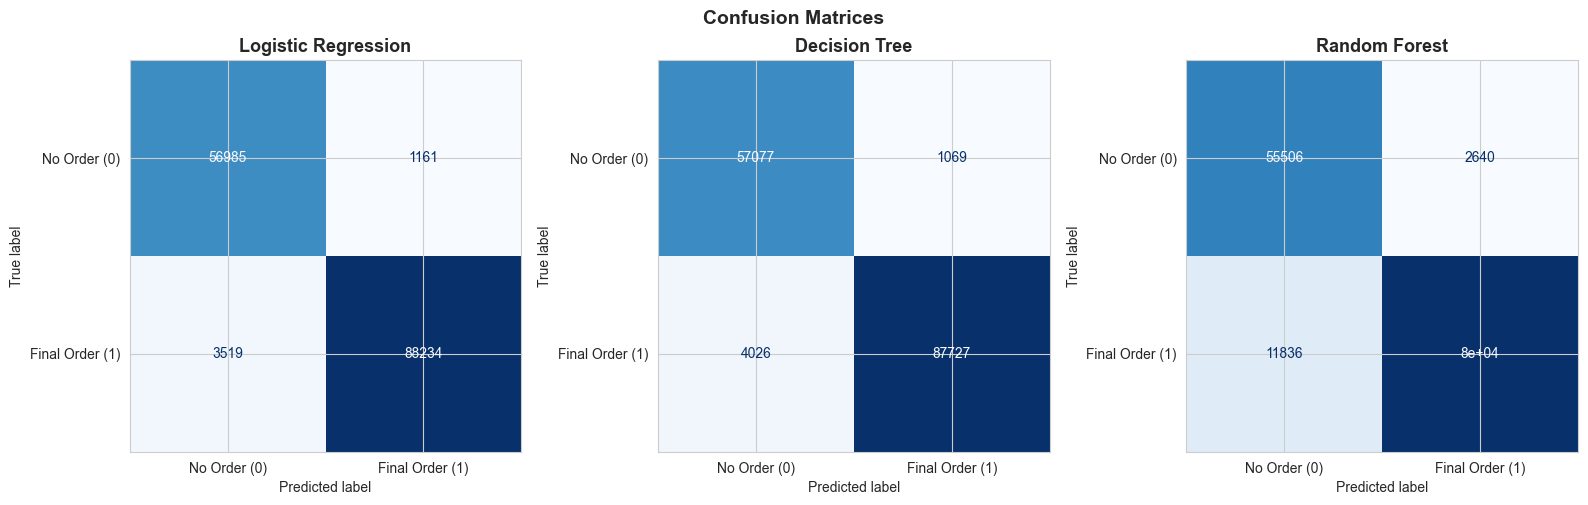

In [ ]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, pipe) in enumerate(fitted_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Order (0)', 'Final Order (1)'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# classification report for best model - logistic regression
best_model_name = max(results, key=lambda k: results[k]['AUC'])
best_pipe = fitted_models[best_model_name]

print(f"=== Best Model: {best_model_name} ===\n")
print(classification_report(
    y_test,
    best_pipe.predict(X_test),
    target_names=['No Final Order', 'Final Order']
))

=== Best Model: Logistic Regression ===

                precision    recall  f1-score   support

No Final Order       0.94      0.98      0.96     58146
   Final Order       0.99      0.96      0.97     91753

      accuracy                           0.97    149899
     macro avg       0.96      0.97      0.97    149899
  weighted avg       0.97      0.97      0.97    149899



### Feature Importance
---
Understanding **which features drive predictions** helps us:
1. Validate the model makes sensible decisions
2. Identify which policy/enforcement factors matter most
3. Flag potentially problematic demographic drivers

We extract importance from:
- **Logistic Regression**: Absolute coefficient magnitudes
- **Random Forest**: Mean decrease in impurity

Logistic Regression and Random Forest were both used to evaluate feature importance. Logistic Regression provides interpretable, direction-based importance through coefficients, making it useful for understanding how features influence the likelihood of the outcome. Random Forest complements this by capturing nonlinear relationships and feature interactions, offering a more robust view of importance. Using both models ensures a more comprehensive and reliable interpretation of key predictors.

#### Logistic Regression Feature Importance

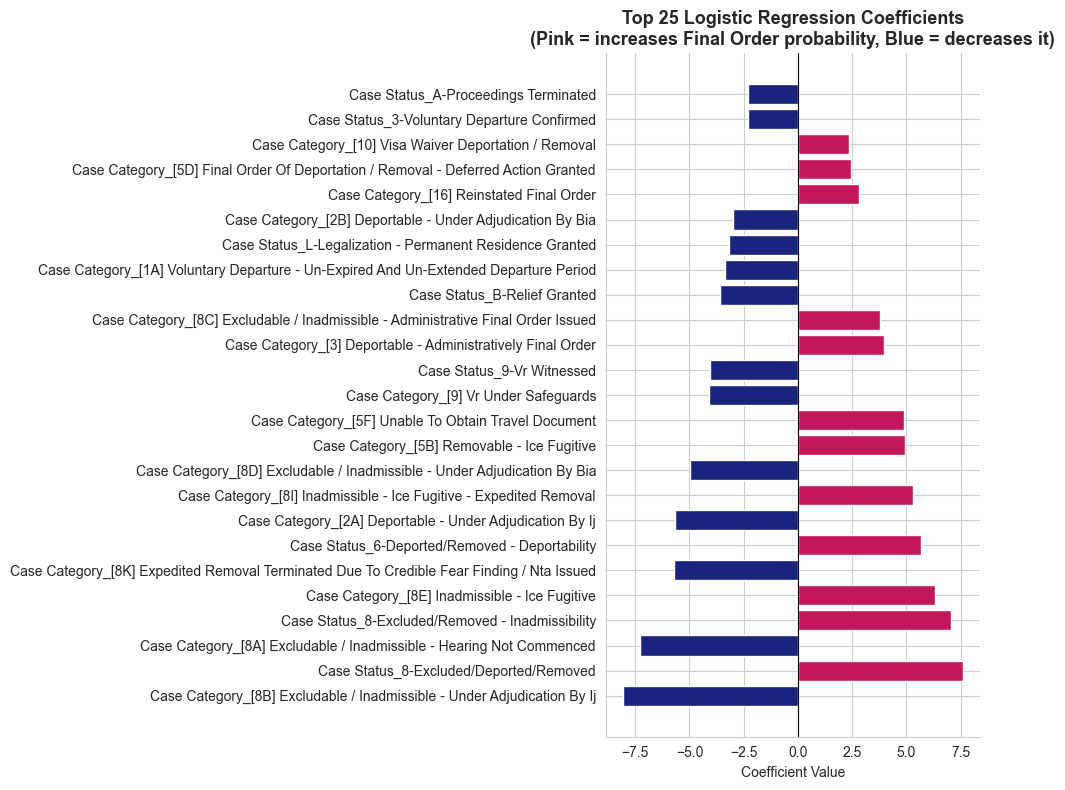

In [14]:
lr_pipe = fitted_models['Logistic Regression']
lr_clf  = lr_pipe.named_steps['classifier']

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_clf.coef_[0]
})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(25)

# Color by direction
coef_df['Color'] = np.where(coef_df['Coefficient'] > 0, PINK, BLUE)

plt.figure(figsize=(10, 8))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=coef_df['Color'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 25 Logistic Regression Coefficients\n(Pink = increases Final Order probability, Blue = decreases it)')
plt.xlabel('Coefficient Value')
sns.despine()
plt.tight_layout()
plt.show()

#### Random Forest Feature Importance

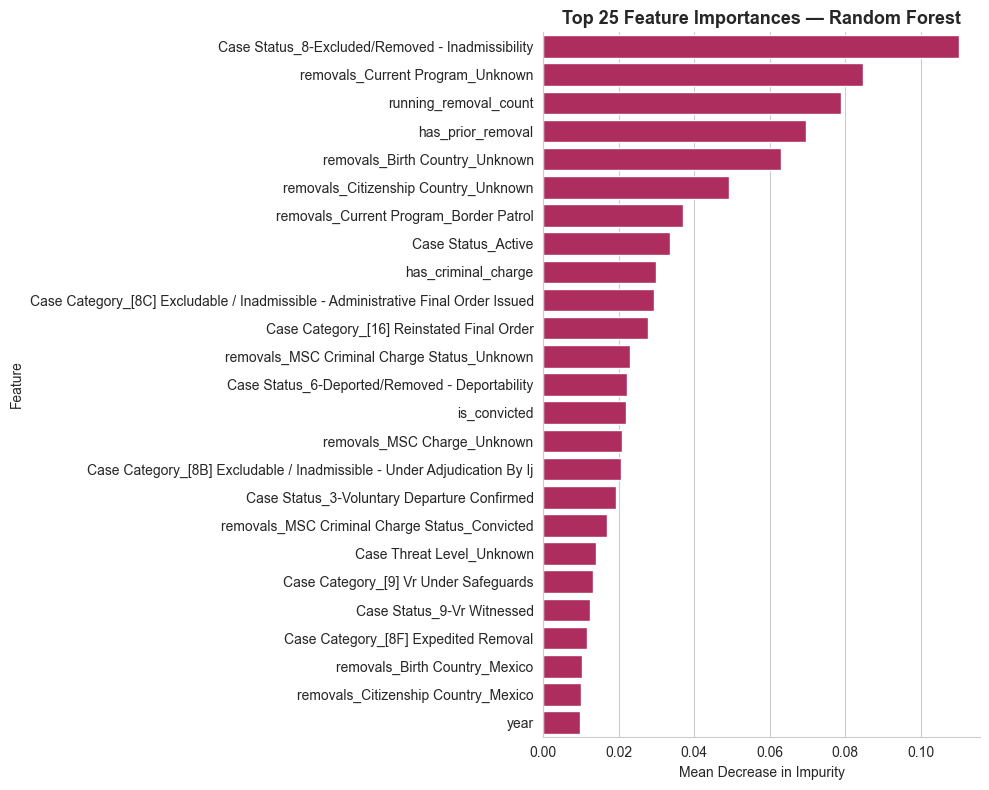


Top 10 features:
                                                                         Feature  Importance
                                Case Status_8-Excluded/Removed - Inadmissibility    0.110225
                                                removals_Current Program_Unknown    0.084656
                                                           running_removal_count    0.078771
                                                               has_prior_removal    0.069590
                                                  removals_Birth Country_Unknown    0.062917
                                            removals_Citizenship Country_Unknown    0.049078
                                          removals_Current Program_Border Patrol    0.036929
                                                              Case Status_Active    0.033524
                                                             has_criminal_charge    0.029806
Case Category_[8C] Excludable / Inadmissible - Admin

In [13]:
rf_pipe = fitted_models['Random Forest']
rf_clf  = rf_pipe.named_steps['classifier']

# Get feature names after one-hot encoding
num_names = NUMERIC_FEATURES
ohe       = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']['encoder']
cat_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
bin_names = BINARY_FEATURES

all_feature_names = num_names + cat_names + bin_names

importances = rf_clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', color=PINK)
plt.title('Top 25 Feature Importances — Random Forest')
plt.xlabel('Mean Decrease in Impurity')
sns.despine()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp_df[['Feature', 'Importance']].head(10).to_string(index=False))

### Fairness & Bias Analysis
--- 
Immigration enforcement decisions have profound real-world consequences. A model that 
performs well overall but systematically over-predicts (or under-predicts) Final Orders 
for specific demographic groups can perpetuate or amplify systemic bias.

**Groups analyzed**
| Group | Definition |
|-------|-----------|
| Hispanic | `is_hispanic == 1` |
| Non-Hispanic | `is_hispanic == 0` |
| Male | `is_male == 1` |
| Female | `is_male == 0` |

**Fairness metrics we use**

| Metric               | Definition                              | Fair if...                          |
|---------------------|------------------------------------------|-------------------------------------|
| **Demographic Parity** | P(ŷ = 1 \| group A) ≈ P(ŷ = 1 \| group B) | Rates roughly equal                 |
| **Equal Opportunity** | TPR equal across groups                 | Same recall for both groups         |
| **Predictive Parity** | Precision equal across groups           | Same precision for both groups      |
| **AUC by group**      | Discriminative ability per group        | Similar AUC values                  |

In [15]:
def compute_fairness_metrics(pipe, X, y, group_series, group_name, threshold=0.5):
    """
    Compute fairness metrics for a binary protected attribute.
    group_series: 0/1 Series aligned with X and y
    """
    y_prob = pipe.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {}
    for val, label in [(1, f'{group_name}=1'), (0, f'{group_name}=0')]:
        mask = group_series == val
        if mask.sum() == 0:
            continue
        g_true = y[mask]
        g_pred = y_pred[mask]
        g_prob = y_prob[mask]

        tp = ((g_true == 1) & (g_pred == 1)).sum()
        fn = ((g_true == 1) & (g_pred == 0)).sum()
        fp = ((g_true == 0) & (g_pred == 1)).sum()
        tn = ((g_true == 0) & (g_pred == 0)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / Equal Opportunity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        pred_rate = g_pred.mean()  # Demographic parity

        try:
            auc = roc_auc_score(g_true, g_prob)
        except ValueError:
            auc = np.nan

        results[label] = {
            'N': int(mask.sum()),
            'Base Rate (actual)': round(g_true.mean(), 4),
            'Pred Rate (demographic parity)': round(pred_rate, 4),
            'TPR / Recall (equal opportunity)': round(tpr, 4),
            'FPR': round(fpr, 4),
            'Precision (pred parity)': round(precision, 4),
            'AUC': round(auc, 4),
        }

    df_out = pd.DataFrame(results).T
    # Disparity ratios (group=1 / group=0)
    try:
        df_out.loc['Disparity Ratio (1/0)', :] = (
            df_out.loc[f'{group_name}=1', :] / df_out.loc[f'{group_name}=0', :]
        ).round(4)
    except Exception:
        pass
    return df_out


print("Fairness metrics function defined.")

Fairness metrics function defined.


In [16]:
# Use the best model
pipe = fitted_models[best_model_name]

print(f"=== FAIRNESS ANALYSIS: {best_model_name} ===\n")

print("─" * 60)
print("GROUP: Hispanic vs. Non-Hispanic")
print("─" * 60)
hispanic_fairness = compute_fairness_metrics(
    pipe, X_test, y_test, g_test['is_hispanic'], group_name='Hispanic'
)
print(hispanic_fairness.to_string())

print("\n")
print("─" * 60)
print("GROUP: Male vs. Female")
print("─" * 60)
gender_fairness = compute_fairness_metrics(
    pipe, X_test, y_test, g_test['is_male'], group_name='Male'
)
print(gender_fairness.to_string())

=== FAIRNESS ANALYSIS: Logistic Regression ===

────────────────────────────────────────────────────────────
GROUP: Hispanic vs. Non-Hispanic
────────────────────────────────────────────────────────────
                               N  Base Rate (actual)  Pred Rate (demographic parity)  TPR / Recall (equal opportunity)     FPR  Precision (pred parity)     AUC
Hispanic=1             52500.000              0.7088                          0.6974                            0.9698  0.0342                   0.9857  0.9963
Hispanic=0             97399.000              0.5600                          0.5419                            0.9561  0.0149                   0.9879  0.9945
Disparity Ratio (1/0)      0.539              1.2657                          1.2870                            1.0143  2.2953                   0.9978  1.0018


────────────────────────────────────────────────────────────
GROUP: Male vs. Female
────────────────────────────────────────────────────────────
          

#### Fairness Analysis — Logistic Regression

The figure compares fairness metrics across **Hispanic vs non-Hispanic groups** and **Male vs non-Male groups** using three key criteria: demographic parity, equal opportunity, and predictive parity. A fairness threshold of 0.8 (shown as a dashed red line) is used as a general benchmark—values closer across groups indicate better fairness.

##### Demographic Parity
Demographic parity measures whether different groups receive positive predictions at similar rates.

- **Hispanic vs Non-Hispanic:** There is a noticeable gap, with Hispanic individuals having a higher predicted positive rate than non-Hispanic individuals.
- **Gender:** A larger disparity is observed, where males receive positive predictions at a much higher rate than non-males.
This suggests potential bias in how predictions are distributed across groups.

#### Equal Opportunity (Recall / TPR)
Equal opportunity evaluates whether the model is equally good at identifying true positives across groups.

- **Hispanic vs Non-Hispanic:** The values are very close, both above the 0.8 threshold.
- **Gender:** Slight difference exists, but both groups still maintain high recall.
This indicates the model performs similarly well in detecting true positive cases across groups.

#### Predictive Parity (Precision)
Predictive parity measures whether predictions are equally reliable across groups.

- **Hispanic vs Non-Hispanic:** Precision is nearly identical and very high for both groups.
- **Gender:** Similarly, precision remains consistent across groups.
This suggests that when the model predicts a positive outcome, it is equally accurate across groups.

#### Overall Interpretation
- The model demonstrates **strong performance in equal opportunity and predictive parity**, meaning it is consistent in identifying and predicting outcomes across groups.
- However, **demographic parity shows notable disparities**, particularly for gender, indicating that some groups are more likely to receive positive predictions overall.
This pattern highlights a common trade-off in fairness:
- The model is **accurate and consistent**, but  
- It may still produce **unequal outcome distributions across demographic groups**

Further steps (such as reweighting or threshold adjustments) may be needed to reduce these disparities while maintaining performance.

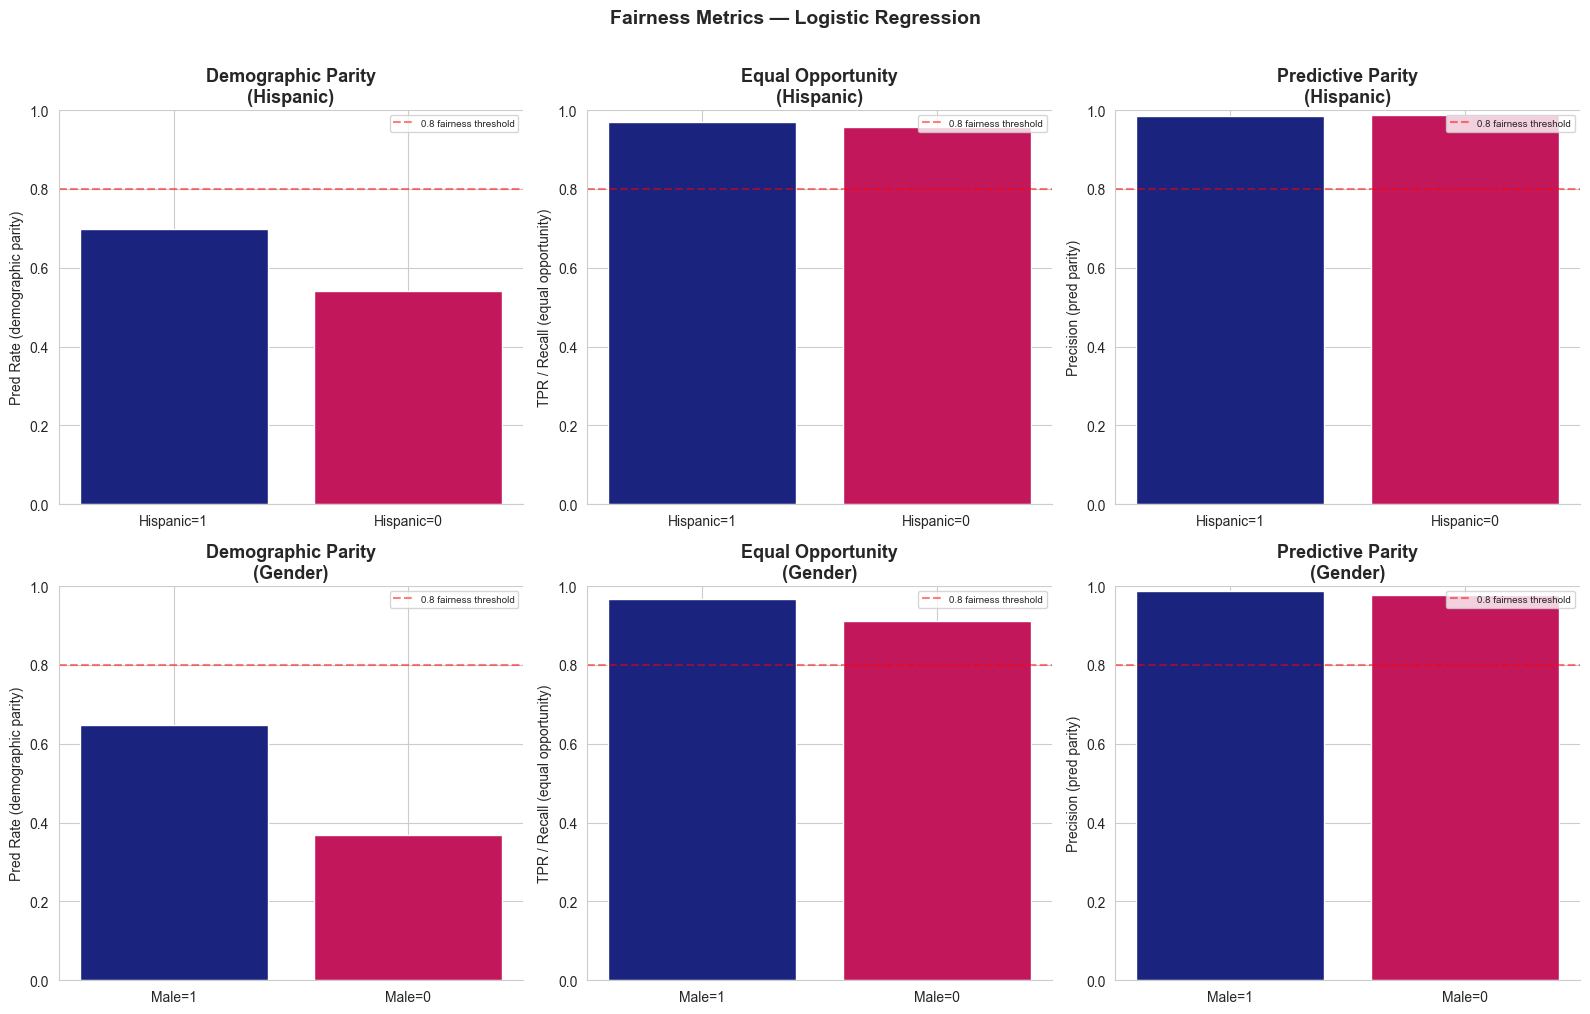

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

def plot_fairness_bar(ax, df, metric, title, colors=None):
    """Plot a single fairness metric comparison."""
    if colors is None:
        colors = [BLUE, PINK]
    # Exclude disparity ratio row
    plot_df = df[~df.index.str.contains('Disparity')]
    ax.bar(plot_df.index, plot_df[metric].astype(float), color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 fairness threshold')
    ax.legend(fontsize=7)
    ax.set_ylabel(metric)
    sns.despine(ax=ax)

# Row 0: Hispanic fairness
plot_fairness_bar(axes[0,0], hispanic_fairness,
                  'Pred Rate (demographic parity)', 'Demographic Parity\n(Hispanic)')
plot_fairness_bar(axes[0,1], hispanic_fairness,
                  'TPR / Recall (equal opportunity)', 'Equal Opportunity\n(Hispanic)')
plot_fairness_bar(axes[0,2], hispanic_fairness,
                  'Precision (pred parity)', 'Predictive Parity\n(Hispanic)')

# Row 1: Gender fairness
plot_fairness_bar(axes[1,0], gender_fairness,
                  'Pred Rate (demographic parity)', 'Demographic Parity\n(Gender)')
plot_fairness_bar(axes[1,1], gender_fairness,
                  'TPR / Recall (equal opportunity)', 'Equal Opportunity\n(Gender)')
plot_fairness_bar(axes[1,2], gender_fairness,
                  'Precision (pred parity)', 'Predictive Parity\n(Gender)')

plt.suptitle(f'Fairness Metrics — {best_model_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

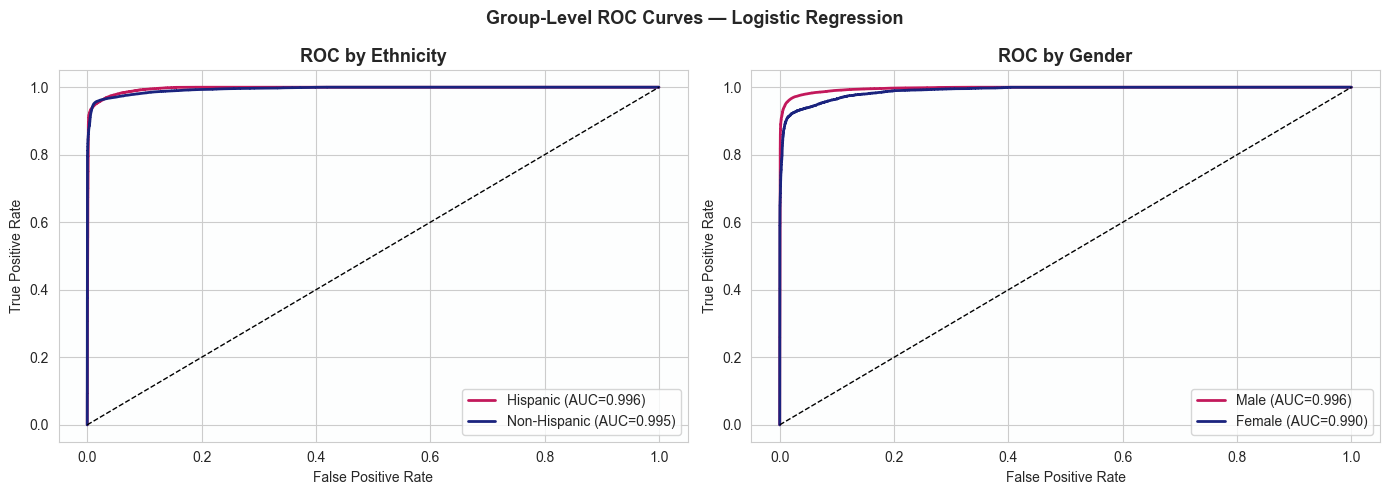

In [18]:
# roc curves by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (group_col, group_name, labels) in zip(
    axes,
    [('is_hispanic', 'Ethnicity', {1: 'Hispanic', 0: 'Non-Hispanic'}),
     ('is_male',     'Gender',    {1: 'Male',     0: 'Female'})]
):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    for val, label in labels.items():
        mask = g_test[group_col] == val
        if mask.sum() < 10:
            continue
        fpr, tpr, _ = roc_curve(y_test[mask], y_prob[mask])
        auc = roc_auc_score(y_test[mask], y_prob[mask])
        color = PINK if val == 1 else BLUE
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')

    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f'ROC by {group_name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.set_facecolor('#FDFEFE')

plt.suptitle(f'Group-Level ROC Curves — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### FAIRNESS IMPROVEMENT?
---